# Boreal polar map of height

In [1]:
library(aws.s3)
#library(rgdal)
library(raster)
library(tidyverse)
library(dplyr)
library(grid)
library(gridExtra)
library(RColorBrewer)
library(data.table)

library(fs)
library(sf)
#library(rgdal)

library(rgeos) # needed for fortify_sf
library(mapproj)
#library(rgee)
library(viridis)
#library(wesanderson)
library(scales)
library(tools)
library(patchwork)

library(rnaturalearth)
library(rnaturalearthdata)
#library(feather)

#conda install -c conda-forge r-rnaturalearth r-rnaturalearthdata r-mapproj r-rgeos r-viridis r-wesanderson r-patchwork r-aws.s3 r-feather r-rockchalk

Loading required package: sp

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ tidyr::extract() masks raster::extract()
✖ dplyr::filter()  masks stats::filter()
✖ dplyr::lag()     masks stats::lag()
✖ dplyr::select()  masks raster::select()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine



Attaching package: ‘data.table’


The following objects are masked from ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


The following objects are masked from ‘package:dplyr’:

    between, first, 

In [2]:
source('/projects/code/3dsi/boreal_map_functions.R') 

[1] "MAAP"
[1] "MAAP"


## Set output figure dir.

In [3]:
OUT_FIGURE_DIR = '/projects/my-public-bucket/boreal_AGB/paper_figs'
dir.create(OUT_FIGURE_DIR)

Warning message in dir.create(OUT_FIGURE_DIR):
“'/projects/my-public-bucket/boreal_AGB/paper_figs' already exists”


#### Figure export function

In [4]:
EXPORT_MAPS_PNG_PDF <- function(m_plot_figure, OUT_FIGURE_DIR, DATA_NAME_STEM, VAR, EXPORT_TIME_STR=format(Sys.time(), "_%Y%m%d"), FIG_DIMS=c(8,16)){
    
    for(OUT_TYPE in c('png', 'pdf')){
        
        map_fn = path(OUT_FIGURE_DIR, paste0("map_",DATA_NAME_STEM,"_", VAR, EXPORT_TIME_STR,".", OUT_TYPE))
        print(map_fn)
        
        ggsave(plot = m_plot_figure,
               file = map_fn,
               device = OUT_TYPE, dpi = 300, width=FIG_DIMS[1], height=FIG_DIMS[2])
    }
}

#### Get all tiles delivered to DAAC for this project

In [4]:
boreal_tile_DAAC_path = '/projects/shared-buckets/montesano/databank/daac/v3.0/boreal_tiles_v004_AGB_H30_2020_ORNLDAAC.gpkg'
boreal_tiles_gcs_DAAC = st_read(boreal_tile_DAAC_path) %>% st_transform(4326)
boreal_tile_num_DAAC_list =  boreal_tiles_gcs_DAAC %>% as.data.frame() %>% dplyr::select(tile_num) %>% as.list()
boreal_tile_num_DAAC_list = unlist(boreal_tile_num_DAAC_list[[1]])
length(boreal_tile_num_DAAC_list)

Reading layer `boreal_tiles_v004_AGB_H30_2020_ORNLDAAC' from data source 
  `/projects/shared-buckets/montesano/databank/daac/v3.0/boreal_tiles_v004_AGB_H30_2020_ORNLDAAC.gpkg' 
  using driver `GPKG'
Simple feature collection with 3902 features and 3 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: -180 ymin: 43.75195 xmax: 180 ymax: 78.53133
Geodetic CRS:  WGS 84


[1] 3902

# Height tile summaries

### Note:  
Model `stats.Rds` for `dev_v1.5` and `v3.0.0` come from a single (the first) rF model - *this does NOT show model ensemble results*


In [6]:
list_HT_tindex_master_fn = c(
   # 's3://maap-ops-workspace/shared/montesano/DPS_tile_lists/BOREAL_MAP/boreal_agb_2024_v6/AGB_H30_2020/Version2_SD/AGB_tindex_master.csv', # For some reason thee files arent readable?
    # 's3://maap-ops-workspace/shared/montesano/DPS_tile_lists/BOREAL_MAP/dev_v1.5/Ht_H30_2020/full_run/HT_tindex_master.csv',
    # 's3://maap-ops-workspace/shared/montesano/DPS_tile_lists/BOREAL_MAP/dev_v1.5/Ht_S1H30_2020/full_run_no_uncert/HT_tindex_master.csv',
    's3://maap-ops-workspace/shared/montesano/DPS_tile_lists/BOREAL_MAP/v3.0.0/Ht_H30_2020/full_run/HT_tindex_master.csv'
    )
for(fn in list_HT_tindex_master_fn){print(fn)}

[1] "s3://maap-ops-workspace/shared/montesano/DPS_tile_lists/BOREAL_MAP/v3.0.0/Ht_H30_2020/full_run/HT_tindex_master.csv"


In [7]:
Sys.setenv("AWS_DEFAULT_REGION" = "us-west-2") 

multiple_versions_df_list = list()

for(tindex_fn in list_HT_tindex_master_fn){

    # Get corresponding Height tindex
    
    
    print(tindex_fn)
    
    # Read the tindex from s3
    HT_tindex_master <- aws.s3::s3read_using(read.csv, object = tindex_fn)
    
    # for each file, loop through to get the total AGB csv
    list_s3_path <- HT_tindex_master$s3_path
    
    single_version_borealstats_df_list = list()
    
    for(fn in list_s3_path){

        ###########################
        # randomForest stats
        # These rF stats data are ONLY from the first rF model from all versions v3.0 and earlier
        #
        df = setNames(data.frame(matrix(ncol = 3)),  c('tile_num', 'r2', 'rmse'))
        #print('Read RDS')
        stats = aws.s3::s3read_using(readRDS, object = gsub('.tif', '_stats.Rds' , fn))
        #print(fn)
        fn_base = unlist(str_split(basename(fn),'.tif'))[1]
        fn_parts_list = unlist(str_split(fn_base, '_'))
        tile_num = fn_parts_list[length(fn_parts_list)]
        
        df$tile_num = as.numeric(tile_num)
        df$r2 = stats[[1]]
        df$rmse = stats[[2]]
        imp_sorted <- as.data.frame(stats$importance) %>% arrange(desc(IncNodePurity))
        imp_sorted$variable <- rownames(imp_sorted)
        df$imp_var_1 = imp_sorted$variable[1]
        df$imp_var_2 = imp_sorted$variable[2]
        df$imp_var_3 = imp_sorted$variable[3]
        df$imp_var_4 = imp_sorted$variable[4]
        df$imp_val_1 = imp_sorted$IncNodePurity[1]
        df$imp_val_2 = imp_sorted$IncNodePurity[2]
        df$imp_val_3 = imp_sorted$IncNodePurity[3]
        df$imp_val_4 = imp_sorted$IncNodePurity[4]

        ##############################
        # AGB stock totals summed across all pixels in [1] tile [2] boreal for each iterations (n=250)
        # These data are useful totals across any version
        #
        smry = aws.s3::s3read_using(read.csv, object = gsub('.tif', '_summary.csv' , fn))
        df$tile_mean_mean_m = mean(smry$tile_mean)
        df$tile_mean_std_m = sd(smry$tile_mean)

        df$boreal_mean_mean_m = mean(smry$boreal_mean)
        df$boreal_mean_std_m = sd(smry$boreal_mean) # This, divided by sqrt(n=250) is a standard error 
        
        single_version_borealstats_df_list[[tile_num]] = df
    }
    
    borealstats_df = do.call('rbind', single_version_borealstats_df_list)
    
    # Capture the version from the tindex path
    dps_version_str = str_split(tindex_fn,'/')[[1]][8] 
    map_version_str = str_split(tindex_fn,'/')[[1]][9]
    run_version_str = str_split(tindex_fn,'/')[[1]][10]
    
    # release_version_str should be our names v2.1, v2.1, v3.0 etc
    if(dps_version_str == 'dev_v1.5' && map_version_str == 'Ht_H30_2020'){release_version_str = 'v2.1'}
    if(dps_version_str == 'dev_v1.5' && map_version_str == 'Ht_S1H30_2020'){release_version_str = 'v2.2'}
    if(dps_version_str == 'v3.0.0'   && map_version_str == 'Ht_H30_2020'){release_version_str = 'v3.0'}

    print(paste(release_version_str, map_version_str, sep=' '))
    
    borealstats_df$DPS_VERSION = dps_version_str
    borealstats_df$MAP_VERSION = map_version_str
    borealstats_df$RUN_VERSION = run_version_str
    borealstats_df$RELEASE_VERSION = release_version_str

    multiple_versions_df_list[[paste(release_version_str, map_version_str, run_version_str ,sep='_')]] = borealstats_df # might need to use with 'run_version_str' if comparing between same map version but different runs. Not likely.
}

all_borealstats_df = do.call('rbind', multiple_versions_df_list)


[1] "s3://maap-ops-workspace/shared/montesano/DPS_tile_lists/BOREAL_MAP/v3.0.0/Ht_H30_2020/full_run/HT_tindex_master.csv"
[1] "v3.0 Ht_H30_2020"


In [29]:
EXPORT_TIME_STR = format(Sys.time(), "_%Y%m%d")

In [30]:
## Save the boreal stats table - take a while to build
write.csv(all_borealstats_df, paste0('/projects/my-public-bucket/DPS_tile_lists/BOREAL_MAP/boreal_stats_HEIGHT_multiple_versions',EXPORT_TIME_STR,'.csv'))

In [37]:
tail(all_borealstats_df)

,tile_num,r2,rmse,imp_var_1,imp_var_2,imp_var_3,imp_var_4,imp_val_1,imp_val_2,imp_val_3,imp_val_4,tile_mean_mean_m,tile_mean_std_m,boreal_mean_mean_m,boreal_mean_std_m,DPS_VERSION,MAP_VERSION,RUN_VERSION,RELEASE_VERSION
,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>
v3.0_Ht_H30_2020_full_run.0003375,3375,0.6380400,3.1748835,elevation,Green,SWIR,TCB,105575.171,52318.620,35650.109,32172.884,9.3998278,0.1948547,9.399828,0.1948547,v3.0.0,Ht_H30_2020,full_run,v3.0
v3.0_Ht_H30_2020_full_run.0003237,3237,0.5053467,3.0090781,TCB,Green,SWIR,slope,43192.689,40812.715,35836.575,32905.552,13.1211755,0.1684948,13.121176,0.1684948,v3.0.0,Ht_H30_2020,full_run,v3.0
v3.0_Ht_H30_2020_full_run.0002259,2259,0.4181914,2.2275062,slope,TCB,Green,tpi,31867.508,19857.724,16703.984,12733.931,9.8720440,0.1410830,9.872044,0.1410830,v3.0.0,Ht_H30_2020,full_run,v3.0
v3.0_Ht_H30_2020_full_run.0002879,2879,0.6096047,3.5478398,elevation,Red,SWIR2,NDVI,117532.431,84915.961,41312.296,35622.655,8.3574291,0.1854485,8.700651,0.2032118,v3.0.0,Ht_H30_2020,full_run,v3.0
v3.0_Ht_H30_2020_full_run.0001174,1174,0.6846705,0.5647373,slope,Green,tpi,NDVI,3946.832,1423.339,1303.903,1172.187,0.4133334,0.0596353,0.000000,0.0000000,v3.0.0,Ht_H30_2020,full_run,v3.0
v3.0_Ht_H30_2020_full_run.0003415,3415,0.5673981,3.4125136,elevation,Red,NDVI,Green,71884.415,64061.206,45768.266,39943.998,11.4371858,0.1794928,11.437186,0.1794928,v3.0.0,Ht_H30_2020,full_run,v3.0


In [56]:
dim(all_borealstats_df %>% filter((RELEASE_VERSION == 'v3.0') & (boreal_mean_mean_m > 0)))

[1] 3003   19

### Join AGB RF stats to boreal tiles

In [12]:
all_borealstats_df = read.csv('/projects/my-public-bucket/DPS_tile_lists/BOREAL_MAP/boreal_stats_HEIGHT_multiple_versions_20250714.csv')

In [ ]:
head(all_borealstats_df)

In [38]:
# stats from SPRING 2022 version
#borealstats_df = read.csv("/projects/shared-buckets/lduncanson/borealstats.csv")

boreal_tiles_gcs_stats = fortify_sf(
                            boreal_tiles_gcs_DAAC %>% 
                            dplyr::select(tile_num) %>% 
                            dplyr::mutate(tile_num = as.numeric(tile_num)
                                          #,s3_path_tindex = AGB_tindex_master_fn
                                         ) %>% 
                            dplyr::left_join(all_borealstats_df, by = c('tile_num' = 'tile_num')) 
                                    )
head(boreal_tiles_gcs_stats %>% drop_na())

Regions defined for each Polygons


,long,lat,order,hole,piece,id,group,tile_num,r2,rmse,⋯,imp_val_3,imp_val_4,tile_mean_mean_m,tile_mean_std_m,boreal_mean_mean_m,boreal_mean_std_m,DPS_VERSION,MAP_VERSION,RUN_VERSION,RELEASE_VERSION
,<dbl>,<dbl>,<int>,<lgl>,<fct>,<chr>,<fct>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>
1,-150.6017,68.07390,1,FALSE,1,1,1.1,3175,0.6122546,2.331647,⋯,25739.018,19079.879,1.790498,0.16265379,0,0,v3.0.0,Ht_H30_2020,full_run,v3.0
2,-151.4968,67.34657,2,FALSE,1,1,1.1,3175,0.6122546,2.331647,⋯,25739.018,19079.879,1.790498,0.16265379,0,0,v3.0.0,Ht_H30_2020,full_run,v3.0
3,-153.4462,67.66538,3,FALSE,1,1,1.1,3175,0.6122546,2.331647,⋯,25739.018,19079.879,1.790498,0.16265379,0,0,v3.0.0,Ht_H30_2020,full_run,v3.0
4,-152.5977,68.40285,4,FALSE,1,1,1.1,3175,0.6122546,2.331647,⋯,25739.018,19079.879,1.790498,0.16265379,0,0,v3.0.0,Ht_H30_2020,full_run,v3.0
5,-150.6017,68.07390,5,FALSE,1,1,1.1,3175,0.6122546,2.331647,⋯,25739.018,19079.879,1.790498,0.16265379,0,0,v3.0.0,Ht_H30_2020,full_run,v3.0
6,-161.3912,66.19049,1,FALSE,1,2,2.1,3545,0.6701324,1.217299,⋯,5890.717,5723.485,1.106532,0.03744776,0,0,v3.0.0,Ht_H30_2020,full_run,v3.0


#### Mapping function

In [39]:
MAP_VAR='tile_mean_mean_m'

In [43]:
PLOT_SF = 0.75

In [40]:
options(repr.plot.width = 16, repr.plot.height =8, repr.plot.res = 300)

DO_MAP_LIST <- function(boreal_tiles_gcs_stats, MAP_VAR='tile_total_agb_mean_pg', 
                        MAP_TITLE='Aboveground woody biomass stock\nensemble mean [Pg]', 
                        MAP_LIMS=c(0, 0.08), MAP_PAL='viridis', 
                        #LABEL=NULL, 
                        LABEL_DF=smry_agb, LABEL_SF=1,
                        DO_DENSITY=FALSE,
                        UNITS='Pg'
                       ){

    m_list = list()
    
    for(release_version_str in levels(factor(boreal_tiles_gcs_stats$RELEASE_VERSION))){
        for(map_version_str in levels(factor(boreal_tiles_gcs_stats$MAP_VERSION))){
            
            LABEL='Total stock: '
            if(DO_DENSITY == TRUE){
                LABEL='Mean density: '
                MAP_VAR = str_replace(MAP_VAR, '_pg', '_mgha')
                UNITS='Mg/ha'
                }
            
            if(is.null(LABEL_DF)){
                LABEL_TEXT=NULL
                }else{
                smry_agb_subset = smry_agb %>% 
                            filter(RELEASE_VERSION == release_version_str) %>% 
                            filter(MAP_VERSION == map_version_str)
                if(LABEL_SF == 0.5){
                    smry_agb_subset = smry_agb_subset %>%
                            mutate(tile_total_C_mean_pg = tile_total_agb_mean_pg * LABEL_SF,	
                                   tile_total_C_sd_pg	= tile_total_agb_sd_pg * LABEL_SF,
                                   boreal_total_C_mean_pg = boreal_total_agb_mean_pg * LABEL_SF,	
                                   boreal_total_C_sd_pg = boreal_total_agb_sd_pg * LABEL_SF
                                   )
                    }
                MAP_VAR_SD = str_replace(MAP_VAR, 'mean', 'sd')
                #LABEL_TEXT = paste0(smry_agb_subset$RELEASE_VERSION, ': ', round(smry_agb_subset[,c(MAP_VAR)], 3), ' ',UNITS, ' +/- ', round(smry_agb_subset[,c(MAP_VAR_SD)], 3))
                LABEL_TEXT = paste0(LABEL, round(smry_agb_subset[,c(MAP_VAR)], 3), ' ',UNITS, ' +/- ', round(smry_agb_subset[,c(MAP_VAR_SD)], 3))
                }


            
            TMP_DF = boreal_tiles_gcs_stats %>% filter((MAP_VERSION == map_version_str) & (RELEASE_VERSION == release_version_str))
            
            if(dim(TMP_DF)[1] > 0){
                version_info = paste(release_version_str, map_version_str)
                print(version_info)
                m_plot = DO_MAP_BOREAL_SP(MAP_EXTENT=extent(-180,180,45,90),  
                                     BOREAL_SHP_FN = wwf_circ_dis_fn,
                                     LAYER_LIST = list(geom_polygon(data = TMP_DF, 
                                                                    aes_string(x = "long", y = "lat", group = "group", fill=MAP_VAR), size=0.1)
                                                      )
                                    ) + 
                    theme(
                        legend.title=element_text(size=rel(1.5)), # 1.25
                        legend.text=element_text(size=rel(1)), #0.75
                        plot.caption = element_text(size = 7)
                    ) +
                    scale_fill_viridis(option = MAP_PAL, limits = MAP_LIMS, oob = scales::squish) +
                    guides(fill=guide_colorbar(title=MAP_TITLE, 
                                               title.position = "top", label.position = "bottom", keywidth = unit(8, "cm"), keyheight = unit(.25, "cm"), nrow=3)) +
                    labs(caption=version_info) +
                    annotate("text", x = Inf, y = Inf, label = LABEL_TEXT, hjust = 1.1, vjust = 1.5, size = 3)
                
                m_list[[paste(release_version_str, map_version_str, sep='_')]] = m_plot
                }
            }
    }
    return(m_list)
}

### Height & Uncertainty >50N+Boreal

[1] "v3.0 Ht_H30_2020"
[1] "Using sf and coercing to Spatial object..."
Reading layer `wwf_circumboreal_Dissolve' from data source 
  `/projects/my-public-bucket/databank/arc/wwf_circumboreal_Dissolve.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 2 features and 4 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -5281040 ymin: -60527.9 xmax: 3959203 ymax: 8747447
Projected CRS: NAD83 / Alaska Albers


Regions defined for each Polygons
Regions defined for each Polygons
Regions defined for each Polygons


[1] "v3.0 Ht_H30_2020"
[1] "Using sf and coercing to Spatial object..."
Reading layer `wwf_circumboreal_Dissolve' from data source 
  `/projects/my-public-bucket/databank/arc/wwf_circumboreal_Dissolve.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 2 features and 4 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -5281040 ymin: -60527.9 xmax: 3959203 ymax: 8747447
Projected CRS: NAD83 / Alaska Albers


Regions defined for each Polygons
Regions defined for each Polygons
Regions defined for each Polygons


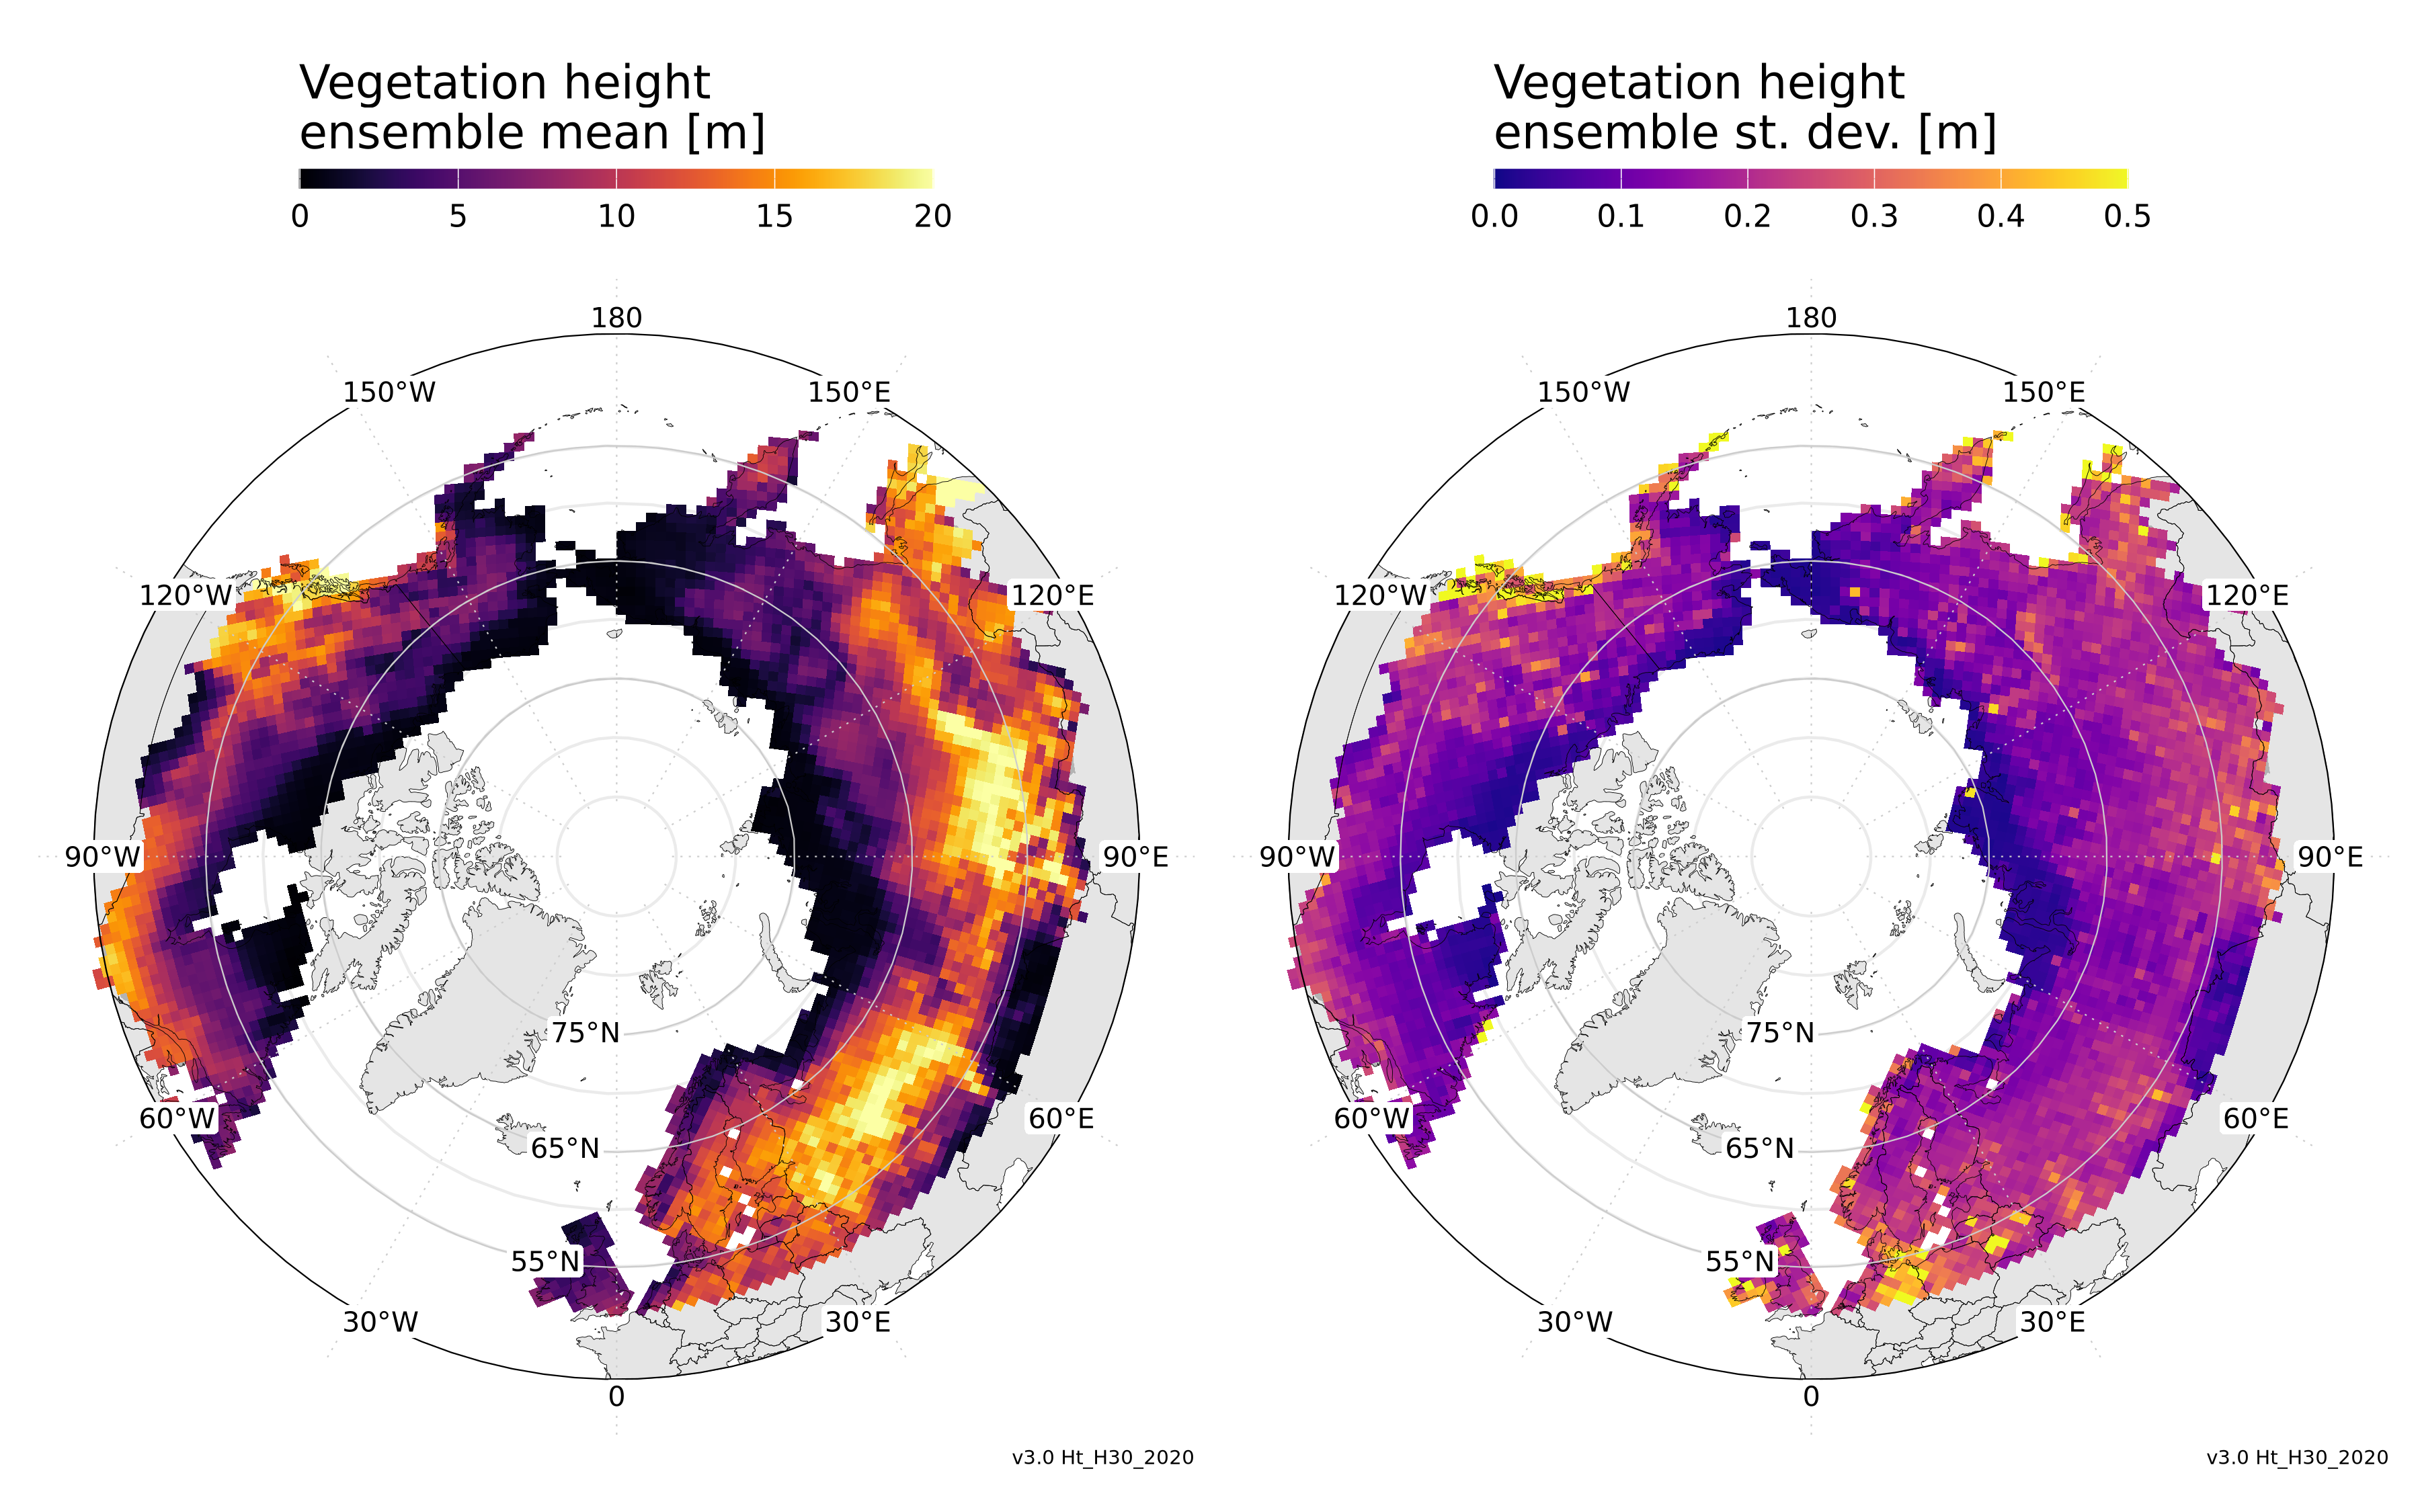

In [52]:
options(repr.plot.width = 16 * PLOT_SF, repr.plot.height = 10 * PLOT_SF, repr.plot.res = 300)

m_TILE_TOTAL_height_mean_list = DO_MAP_LIST(boreal_tiles_gcs_stats %>% filter(RELEASE_VERSION == 'v3.0'), MAP_VAR='tile_mean_mean_m', 
                                  MAP_TITLE='Vegetation height\ntile-level ensemble mean [m]', MAP_LIMS=c(0, 20), MAP_PAL='inferno',
                                LABEL_DF=NULL, DO_DENSITY=TRUE)

m_TILE_TOTAL_height_sd_list = DO_MAP_LIST(boreal_tiles_gcs_stats %>% filter(RELEASE_VERSION == 'v3.0'), MAP_VAR='tile_mean_std_m', 
                                  MAP_TITLE='Vegetation height\ntile-level ensemble st. dev. [m]', MAP_LIMS=c(0, 0.5), MAP_PAL='plasma',
                                LABEL_DF=NULL, DO_DENSITY=TRUE)

m_TILE_mean = m_TILE_TOTAL_height_mean_list[[1]] | m_TILE_TOTAL_height_sd_list[[1]]
m_TILE_mean

### Use for MAAP STAC thumbnail

In [53]:
EXPORT_MAPS_PNG_PDF(m_TILE_mean, OUT_FIGURE_DIR, 'tile_height', 'MEAN', EXPORT_TIME_STR=format(Sys.time(), "_%Y%m%d"), FIG_DIMS=c(16,10))

/projects/my-public-bucket/boreal_AGB/paper_figs/map_tile_height_MEAN_20250714.png
/projects/my-public-bucket/boreal_AGB/paper_figs/map_tile_height_MEAN_20250714.pdf


### Height & Uncertainty in Boreal

[1] "v3.0 Ht_H30_2020"
[1] "Using sf and coercing to Spatial object..."
Reading layer `wwf_circumboreal_Dissolve' from data source 
  `/projects/my-public-bucket/databank/arc/wwf_circumboreal_Dissolve.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 2 features and 4 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -5281040 ymin: -60527.9 xmax: 3959203 ymax: 8747447
Projected CRS: NAD83 / Alaska Albers


Regions defined for each Polygons
Regions defined for each Polygons
Regions defined for each Polygons


[1] "v3.0 Ht_H30_2020"
[1] "Using sf and coercing to Spatial object..."
Reading layer `wwf_circumboreal_Dissolve' from data source 
  `/projects/my-public-bucket/databank/arc/wwf_circumboreal_Dissolve.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 2 features and 4 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -5281040 ymin: -60527.9 xmax: 3959203 ymax: 8747447
Projected CRS: NAD83 / Alaska Albers


Regions defined for each Polygons
Regions defined for each Polygons
Regions defined for each Polygons


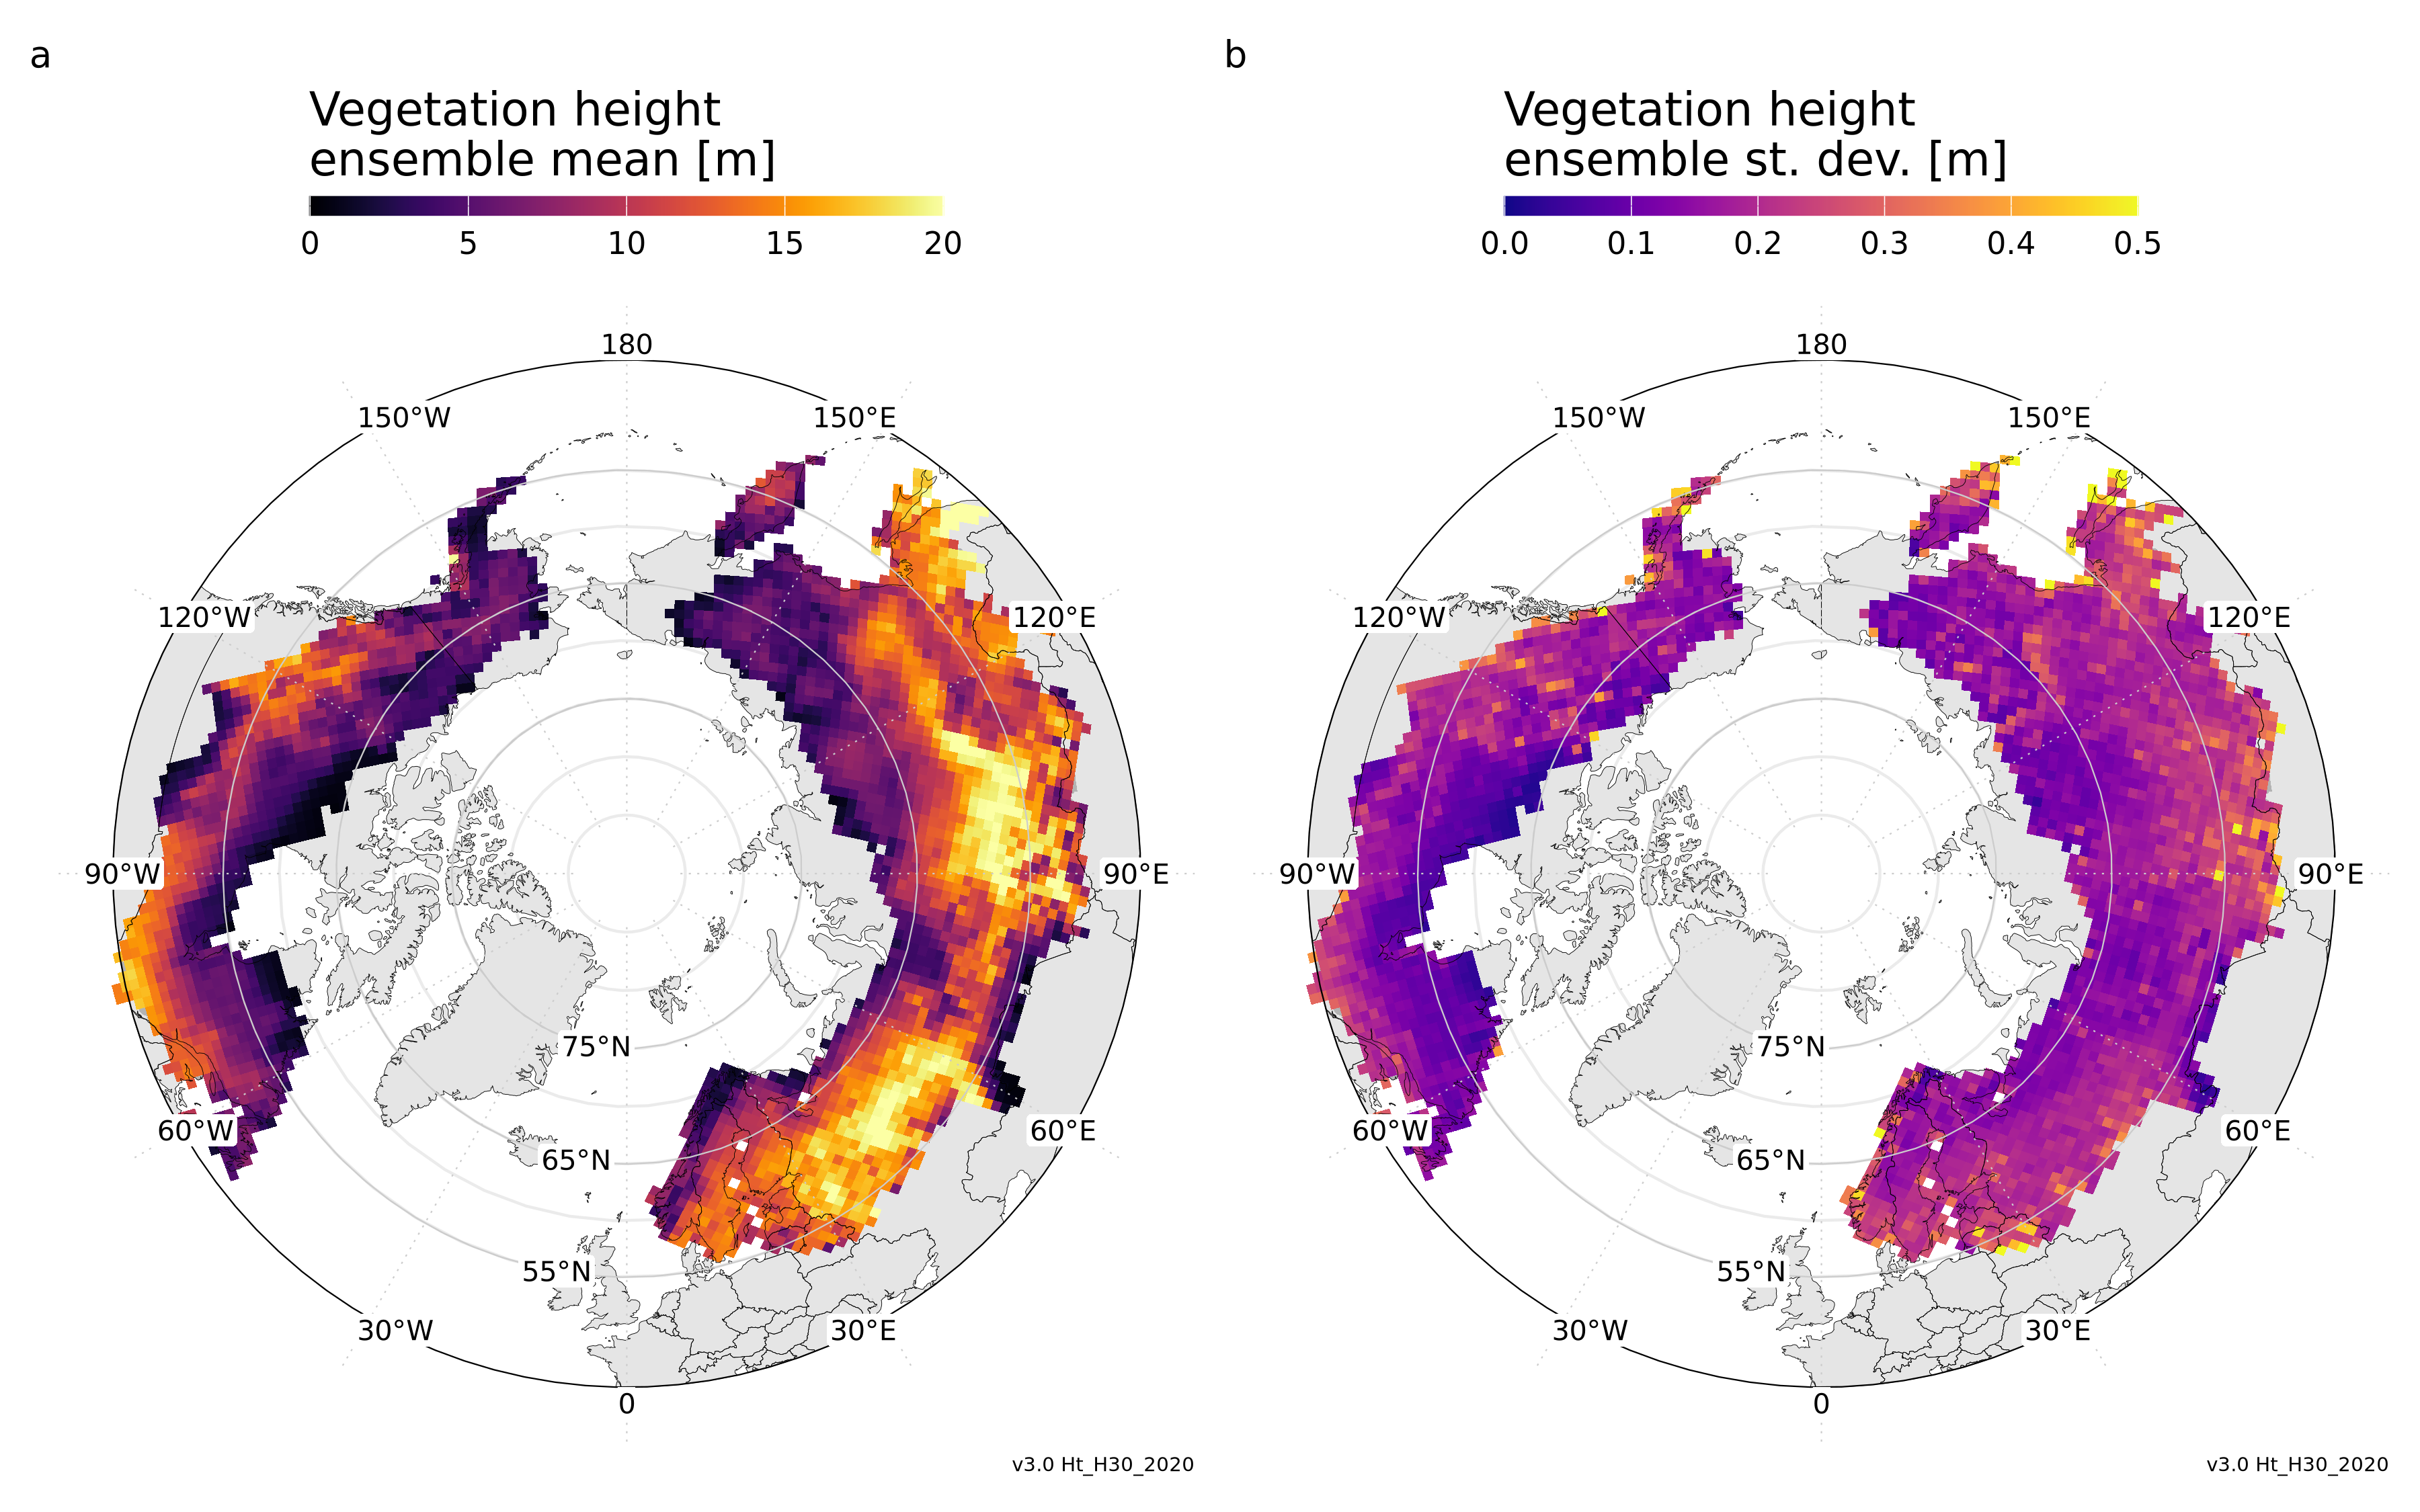

In [54]:
options(repr.plot.width = 16 * PLOT_SF, repr.plot.height = 10 * PLOT_SF, repr.plot.res = 300)

m_BOREAL_height_mean_list = DO_MAP_LIST(boreal_tiles_gcs_stats %>% filter(RELEASE_VERSION == 'v3.0') %>% 
                                              filter(boreal_mean_mean_m > 0), 
                                              MAP_VAR='boreal_mean_mean_m', 
                                  MAP_TITLE='Vegetation height\ntile-level ensemble mean [m]', MAP_LIMS=c(0, 20), MAP_PAL='inferno',
                                 LABEL_DF=NULL, DO_DENSITY=FALSE)

m_BOREAL_height_sd_list = DO_MAP_LIST(boreal_tiles_gcs_stats %>% filter(RELEASE_VERSION == 'v3.0') %>% 
                                              filter(boreal_mean_mean_m > 0), 
                                              MAP_VAR='boreal_mean_std_m', 
                                  MAP_TITLE='Vegetation height\ntile-level ensemble st. dev. [m]', MAP_LIMS=c(0, 0.5), MAP_PAL='plasma',
                                 LABEL_DF=NULL, DO_DENSITY=FALSE)

m_BOREAL_height = (m_BOREAL_height_mean_list[[1]] | m_BOREAL_height_sd_list[[1]]) +
    plot_annotation(tag_levels = "a")  
m_BOREAL_height

In [55]:
EXPORT_MAPS_PNG_PDF(m_BOREAL_height, OUT_FIGURE_DIR, 'BOREAL_height', 'MEAN', EXPORT_TIME_STR=format(Sys.time(), "_%Y%m%d"), FIG_DIMS=c(16,10))

/projects/my-public-bucket/boreal_AGB/paper_figs/map_BOREAL_height_MEAN_20250714.png
/projects/my-public-bucket/boreal_AGB/paper_figs/map_BOREAL_height_MEAN_20250714.pdf


## Export figure: model stats

In [148]:
VAR = 'h_can'

In [465]:
DATA_NAME_STEM = "boreal_model_stats"
EXPORT_TIME_STR = format(Sys.time(), "_%Y%m%d")

EXPORT_MAPS_PNG_PDF(OUT_FIGURE_DIR, DATA_NAME_STEM, EXPORT_TIME_STR)

# Below, these stats are NOT an ensemble result

In [40]:
tail(boreal_tiles_gcs_stats)

,long,lat,order,hole,piece,id,group,tile_num,X,r2,⋯,boreal_total_agb_mean_pg,boreal_total_agb_sd_pg,DPS_VERSION,MAP_VERSION,RUN_VERSION,RELEASE_VERSION,tile_total_agb_mean_mgha,tile_total_agb_sd_mgha,boreal_total_agb_mean_mgha,boreal_total_agb_sd_mgha
,<dbl>,<dbl>,<int>,<lgl>,<fct>,<chr>,<fct>,<dbl>,<chr>,<dbl>,⋯,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
58515,119.6783,47.86846,5,FALSE,1,11703,11703.1,3780,v2.2_AGB_S1H30_2020_full_run_no_uncert.0003780,0.7323895,⋯,0.02406878,NA,dev_v1.5,AGB_S1H30_2020,full_run_no_uncert,v2.2,62.97837,NA,29.71454,NA
58516,119.6783,47.86846,1,FALSE,1,11704,11704.1,3780,v3.0_AGB_H30_2020_full_run.0003780,0.6857296,⋯,0.02331841,0.0005381287,v3.0.0,AGB_H30_2020,full_run,v3.0,63.07202,1.41848,28.78816,0.6643564
58517,120.4345,48.50147,2,FALSE,1,11704,11704.1,3780,v3.0_AGB_H30_2020_full_run.0003780,0.6857296,⋯,0.02331841,0.0005381287,v3.0.0,AGB_H30_2020,full_run,v3.0,63.07202,1.41848,28.78816,0.6643564
58518,121.3642,47.98337,3,FALSE,1,11704,11704.1,3780,v3.0_AGB_H30_2020_full_run.0003780,0.6857296,⋯,0.02331841,0.0005381287,v3.0.0,AGB_H30_2020,full_run,v3.0,63.07202,1.41848,28.78816,0.6643564
58519,120.6038,47.35656,4,FALSE,1,11704,11704.1,3780,v3.0_AGB_H30_2020_full_run.0003780,0.6857296,⋯,0.02331841,0.0005381287,v3.0.0,AGB_H30_2020,full_run,v3.0,63.07202,1.41848,28.78816,0.6643564
58520,119.6783,47.86846,5,FALSE,1,11704,11704.1,3780,v3.0_AGB_H30_2020_full_run.0003780,0.6857296,⋯,0.02331841,0.0005381287,v3.0.0,AGB_H30_2020,full_run,v3.0,63.07202,1.41848,28.78816,0.6643564


In [83]:
options(repr.plot.width = 6, repr.plot.height = 6, repr.plot.res = 300)
# Show map of HLS compositing params
custom_theme = list(
                    theme(
                        legend.title=element_text(size=rel(1.5)), # 1.25
                        legend.text=element_text(size=rel(1)), #0.75
                        plot.caption = element_text(size = 7)
                    ))
m_rmse = DO_MAP_BOREAL_SP(MAP_EXTENT=extent(-180,180,45,90),  
                     BOREAL_SHP_FN = wwf_circ_dis_fn,
                     LAYER_LIST = list(geom_polygon(data = boreal_tiles_gcs_stats %>% 
                                                    filter(DPS_VERSION == 'v3.0.0'), 
                                                    aes(x = long, y = lat, group = group, fill=rmse), size=0.1)
                                      )
                    ) + 
    custom_theme +
    guides(fill=guide_colourbar(title=expression("First rF model RMSE ["~Mg~ha^{-1}~"]"), title.position = "top", label.position = "bottom", keywidth = unit(8, "cm"), keyheight = unit(.25, "cm"), nrow=1))+
    scale_fill_viridis(option = 'rocket')

m_r2 = DO_MAP_BOREAL_SP(MAP_EXTENT=extent(-180,180,45,90),  
                     BOREAL_SHP_FN = wwf_circ_dis_fn,
                     LAYER_LIST = list(geom_polygon(data = boreal_tiles_gcs_stats %>%
                                                    filter(DPS_VERSION == 'v3.0.0'), 
                                                    aes(x = long, y = lat, group = group, fill=r2), size=0.1)
                                      )
                    ) + 
    custom_theme +
    guides(fill=guide_colourbar(title=expression("First rF model "~R^{2}), title.position = "top", label.position = "bottom", keywidth = unit(8, "cm"), keyheight = unit(.25, "cm"), nrow=1))+
    scale_fill_viridis(option = 'turbo')


[1] "Using sf and coercing to Spatial object..."
Reading layer `wwf_circumboreal_Dissolve' from data source 
  `/projects/my-public-bucket/databank/arc/wwf_circumboreal_Dissolve.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 2 features and 4 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -5281040 ymin: -60527.9 xmax: 3959203 ymax: 8747447
Projected CRS: NAD83 / Alaska Albers


Regions defined for each Polygons
Regions defined for each Polygons
Regions defined for each Polygons


[1] "Using sf and coercing to Spatial object..."
Reading layer `wwf_circumboreal_Dissolve' from data source 
  `/projects/my-public-bucket/databank/arc/wwf_circumboreal_Dissolve.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 2 features and 4 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -5281040 ymin: -60527.9 xmax: 3959203 ymax: 8747447
Projected CRS: NAD83 / Alaska Albers


Regions defined for each Polygons
Regions defined for each Polygons
Regions defined for each Polygons


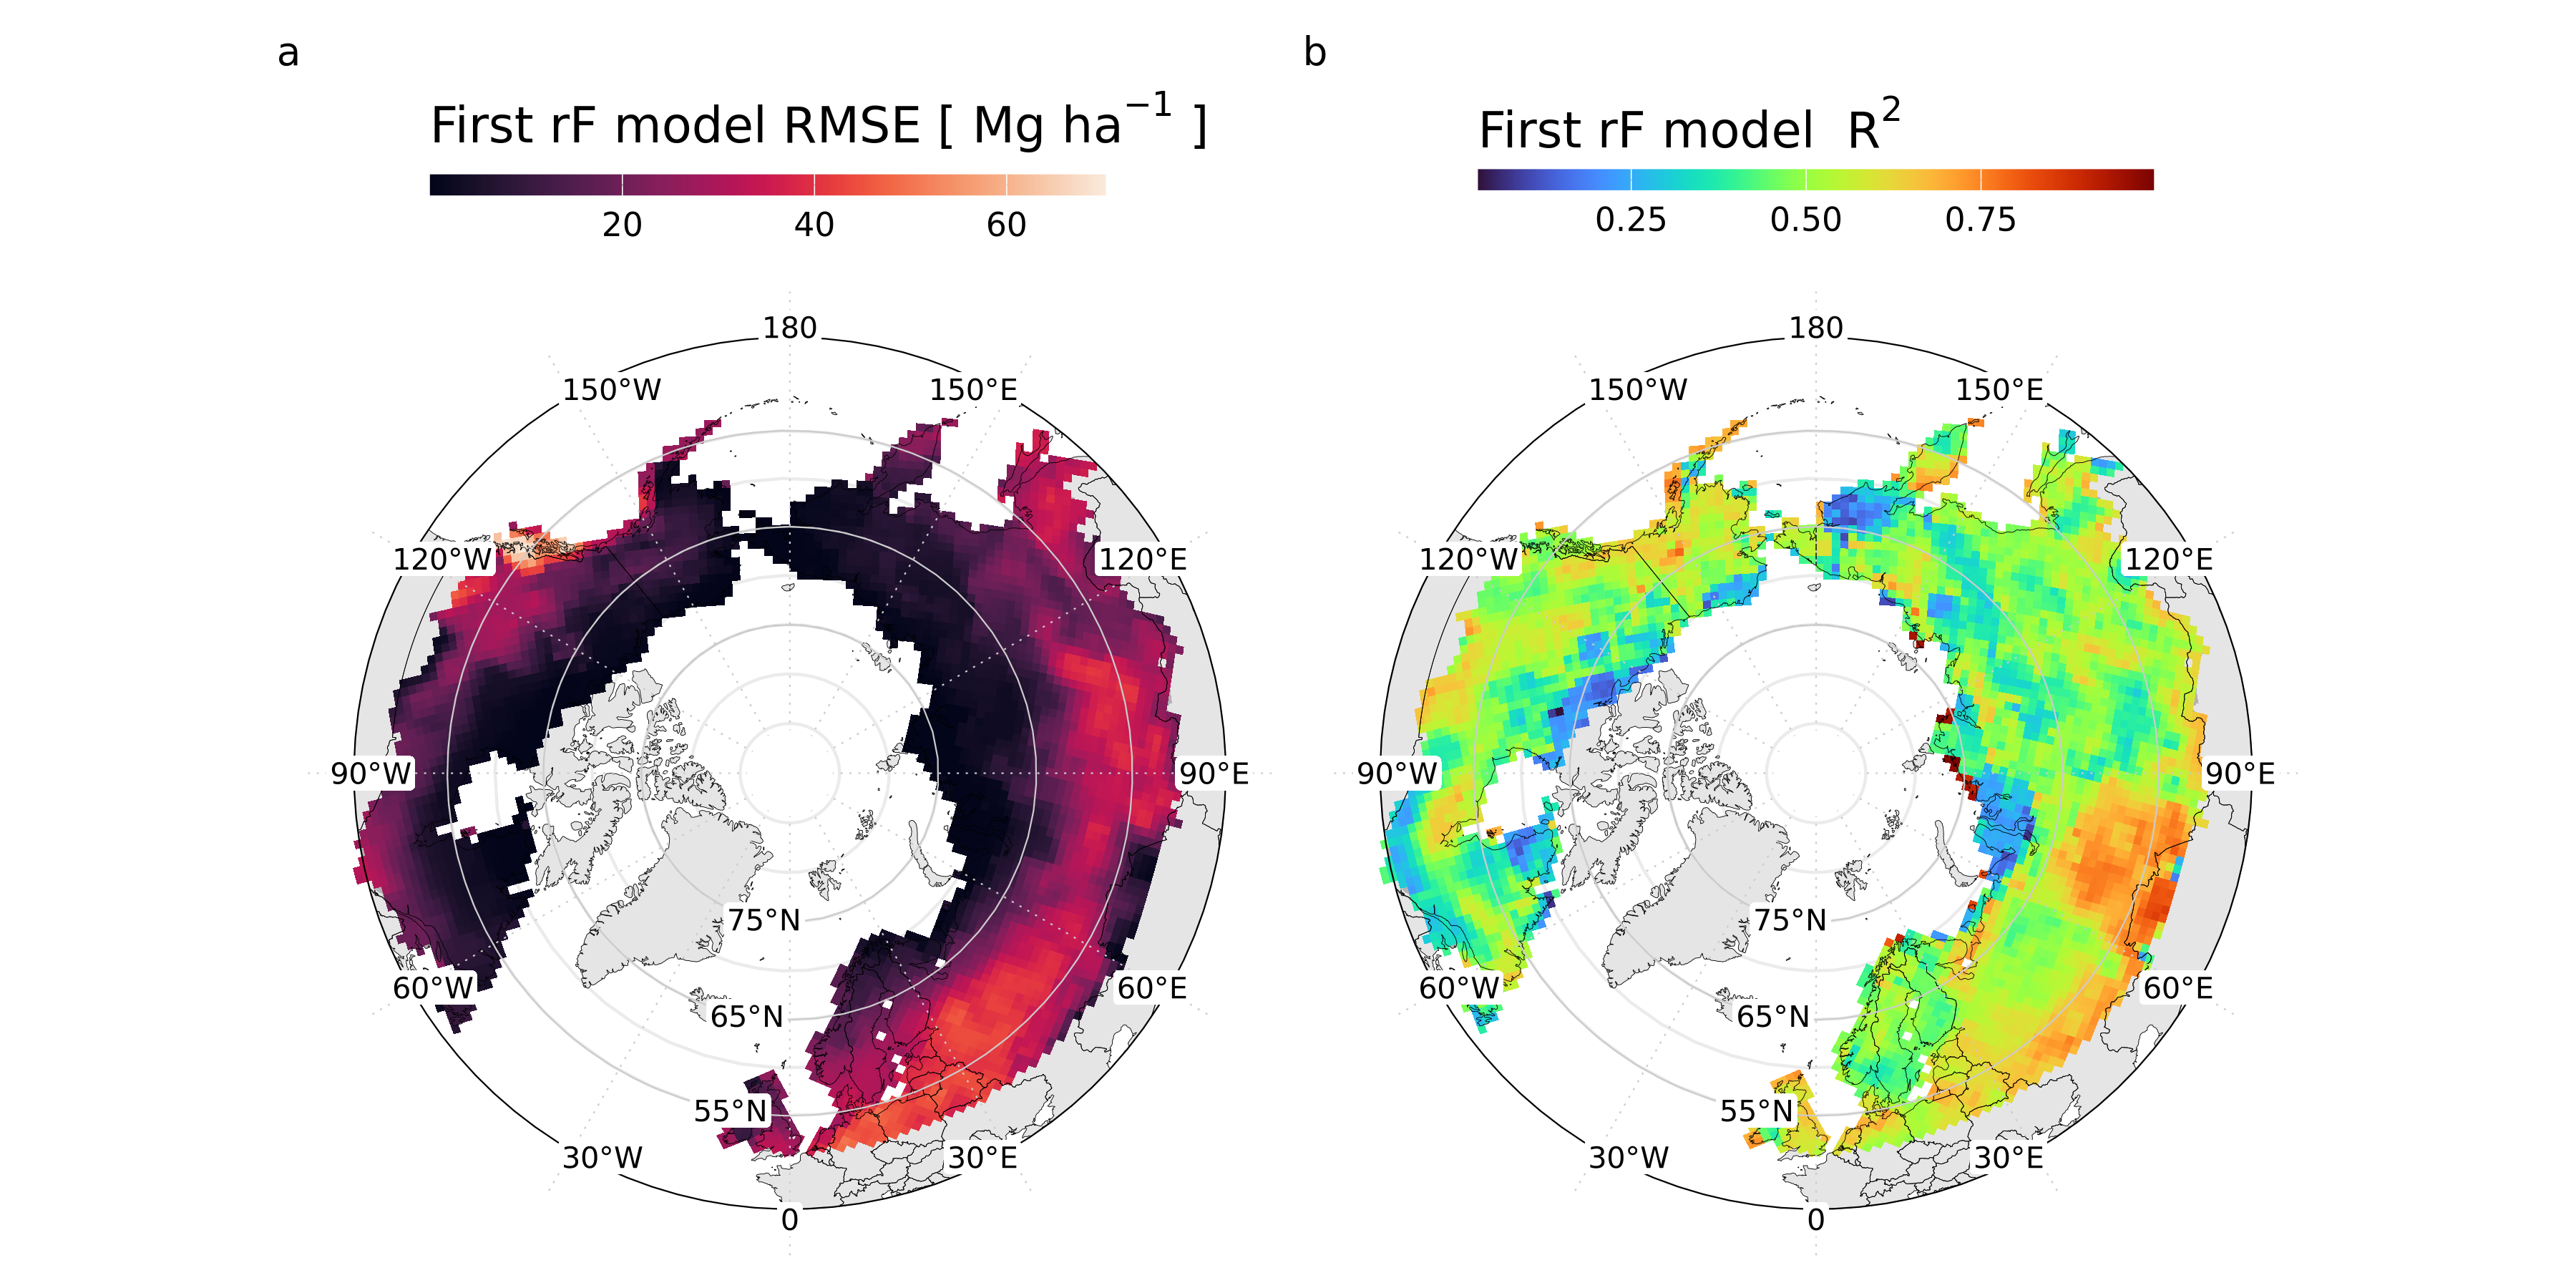

In [84]:
options(repr.plot.width = 16 * PLOT_SF, repr.plot.height = 8 * PLOT_SF, repr.plot.res = 300)

p_boreal_model_stats = (m_rmse | m_r2) +
          plot_annotation(tag_levels = "a")  

p_boreal_model_stats

In [85]:
hist_rmse = ggplot(all_borealstats_df %>% filter(RELEASE_VERSION == 'v3.0')) +
    geom_histogram(aes(x=rmse, fill=factor(rmse)), show.legend=FALSE)+
    scale_fill_viridis_d(option='rocket', direction=1) +
    theme_bw() +
    custom_theme +
    labs(x='First rF model RMSE [m]')
hist_r2 = ggplot(all_borealstats_df %>% filter(RELEASE_VERSION == 'v3.0')) +
    geom_histogram(aes(x=r2, fill=factor(r2)), show.legend=FALSE)+
    scale_fill_viridis_d(option='turbo', direction=1) +
    theme_bw() +
    custom_theme +
labs(x=expression("First rF model "~R^{2}))


first_model_stats = (hist_rmse | hist_r2)

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


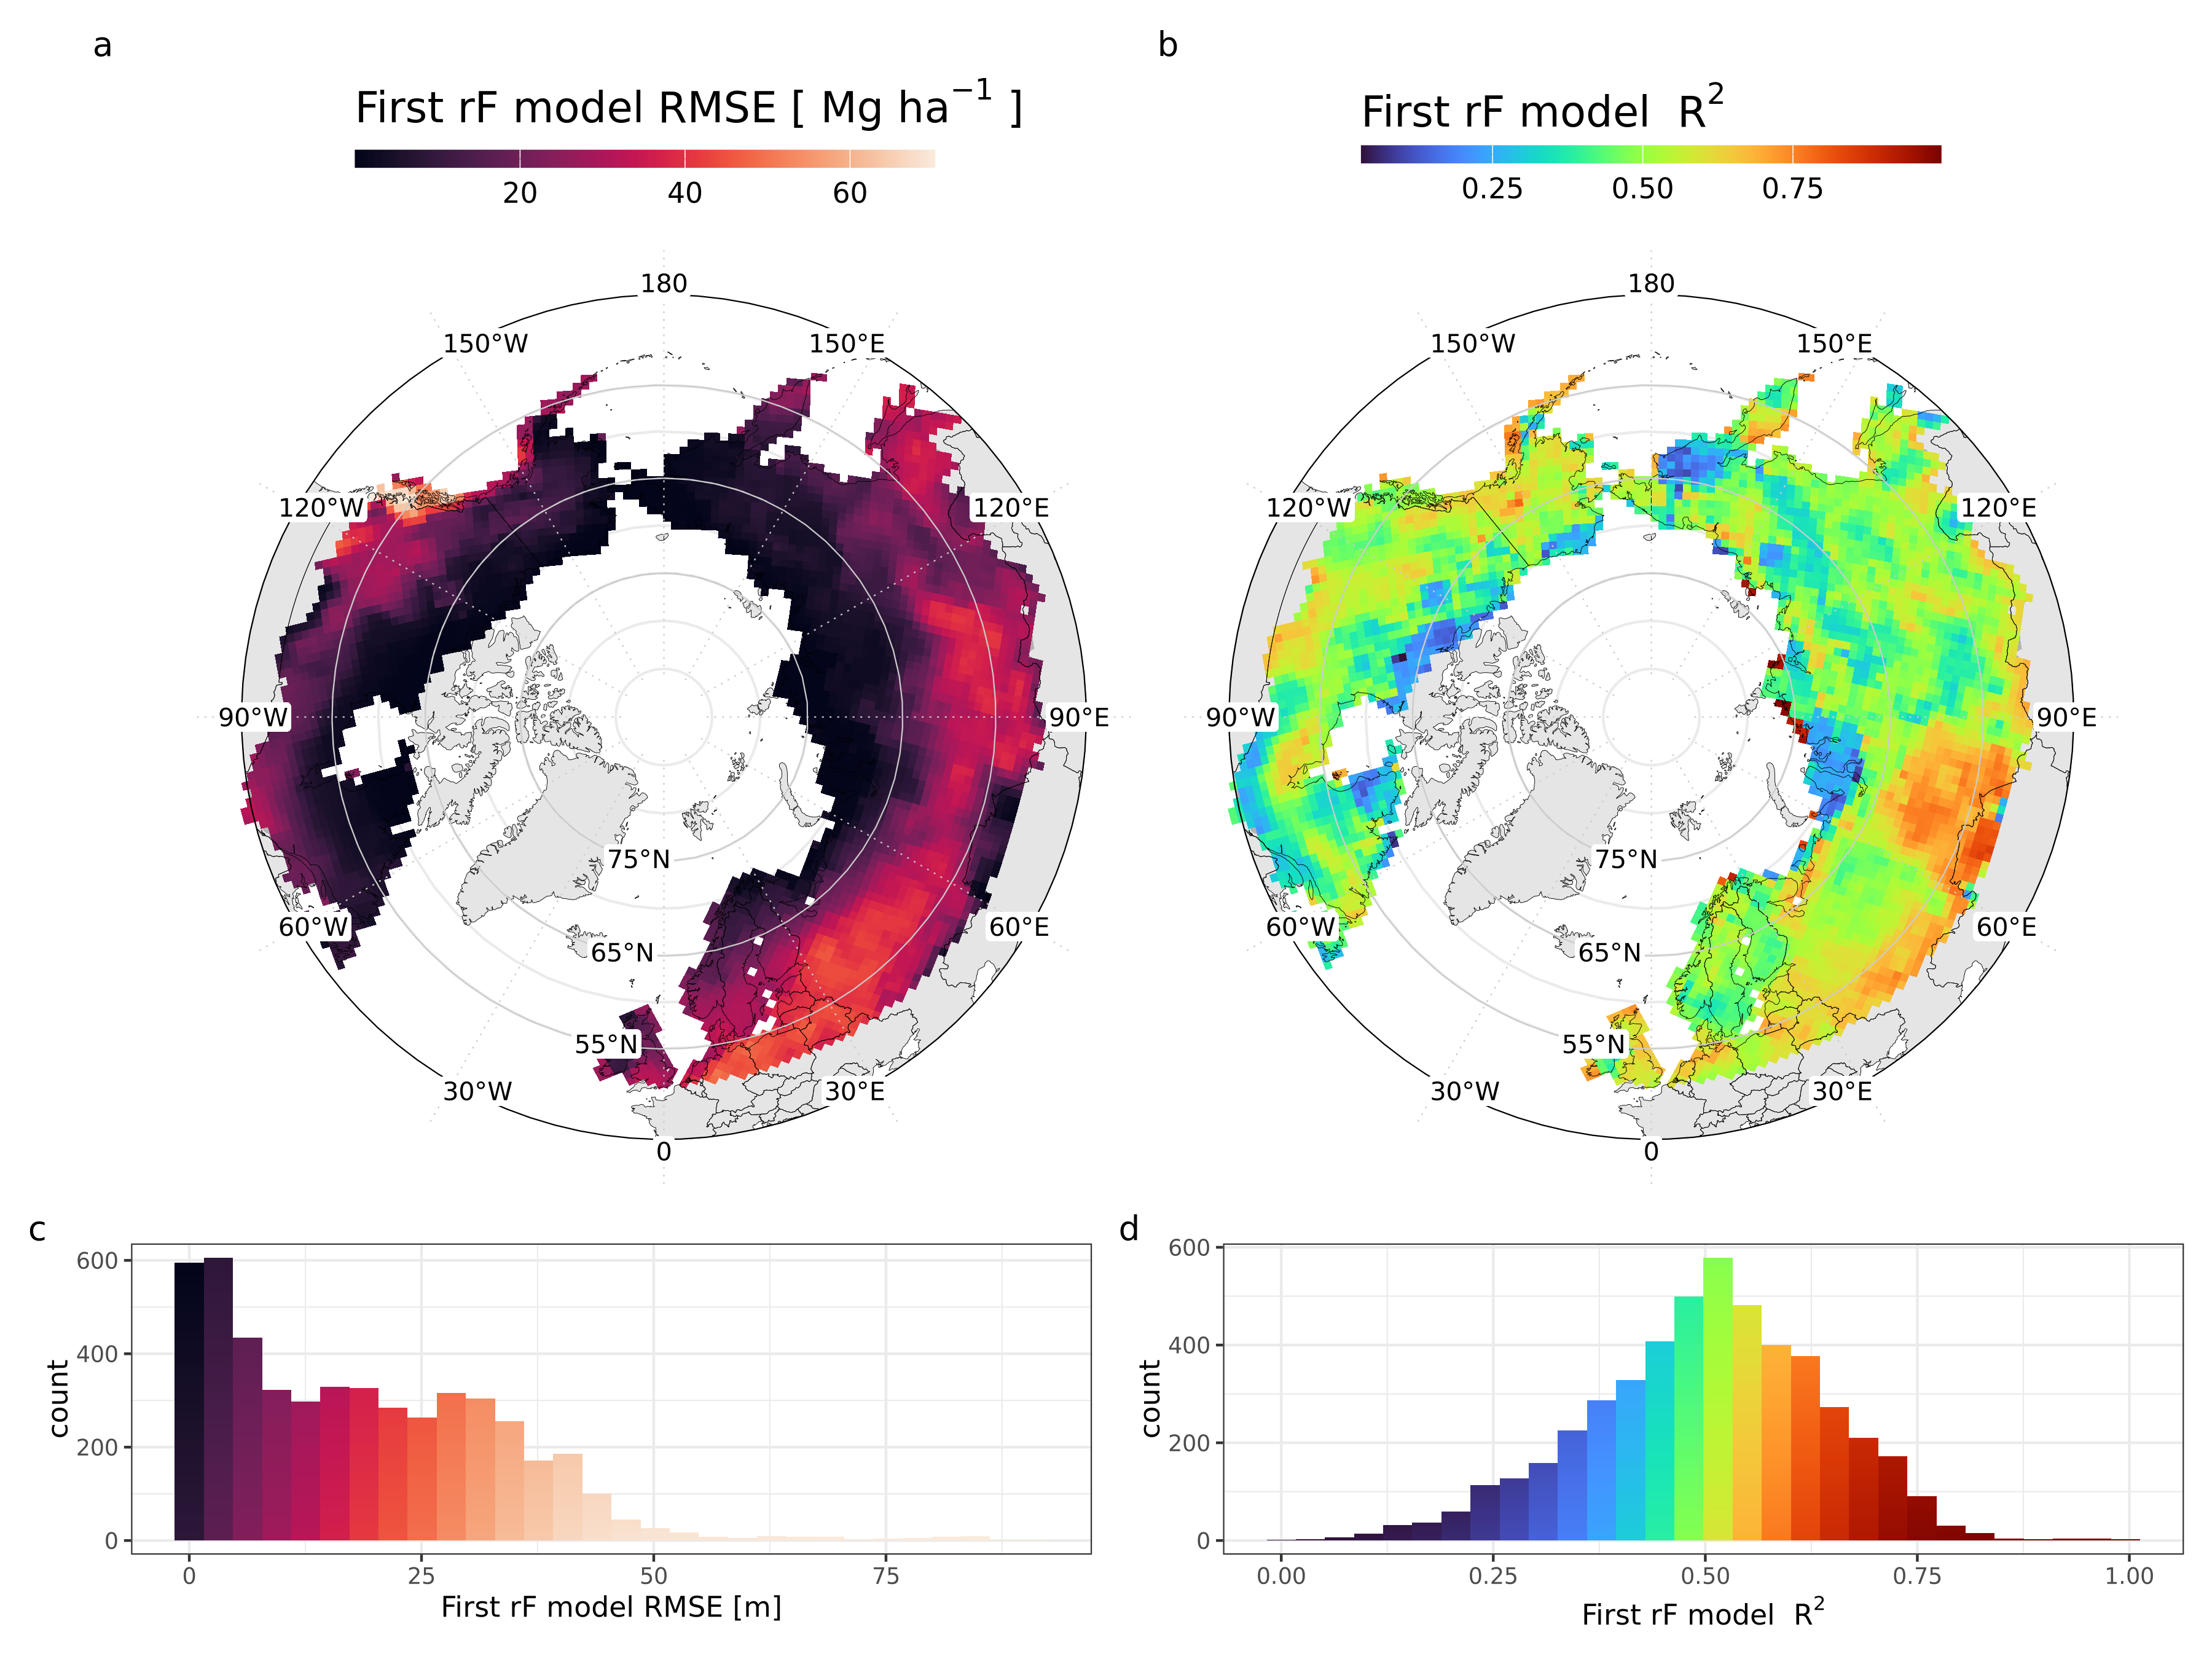

In [86]:
options(repr.plot.width = 16 * PLOT_SF, repr.plot.height = 12 * PLOT_SF, repr.plot.res = 300, warn=-1)

layout = "
AA
AA
AA
BB
"
combined_first_model_stats = (p_boreal_model_stats / first_model_stats) +
    plot_layout(design = layout) +
    plot_annotation(tag_levels = 'a') #+ theme(plot.tag = element_text(size = 26))

combined_first_model_stats

In [87]:
EXPORT_MAPS_PNG_PDF(combined_first_model_stats, OUT_FIGURE_DIR, 'BOREAL_MODEL_STATS_AGB', 'FIRST', EXPORT_TIME_STR=format(Sys.time(), "_%Y%m%d"), FIG_DIMS=c(16,10))

/projects/my-public-bucket/boreal_AGB/paper_figs/map_BOREAL_MODEL_STATS_AGB_FIRST_20250711.png


`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


/projects/my-public-bucket/boreal_AGB/paper_figs/map_BOREAL_MODEL_STATS_AGB_FIRST_20250711.pdf


`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


In [187]:
boreal_tiles_gcs_stats_varimp_m = melt(boreal_tiles_gcs_stats %>% select('tile_num','long','lat','group','imp_var_1','imp_var_2','imp_var_3','imp_var_4'), id.vars=c('tile_num','long','lat','group'), meas.vars=c('imp_var_1','imp_var_2','imp_var_3','imp_var_4'))

Warning message:
“c("The melt generic in data.table has been passed a data.frame and will attempt to redirect to the relevant reshape2 method; please note that reshape2 is superseded and is no longer actively developed, and this redirection is now deprecated. To continue using melt methods from reshape2 while both libraries are attached, e.g. melt.list, you can prepend the namespace, i.e. reshape2::melt(boreal_tiles_gcs_stats %>% select(\"tile_num\", \"long\", \"lat\", ). In the next version, this warning will become an error.", 
"The melt generic in data.table has been passed a data.frame and will attempt to redirect to the relevant reshape2 method; please note that reshape2 is superseded and is no longer actively developed, and this redirection is now deprecated. To continue using melt methods from reshape2 while both libraries are attached, e.g. melt.list, you can prepend the namespace, i.e. reshape2::melt(    \"group\", \"imp_var_1\", \"imp_var_2\", \"imp_var_3\", \"imp_var_4\")). 

In [195]:
dim(boreal_tiles_gcs_stats_varimp_m)
dim(boreal_tiles_gcs_stats_varimp_m %>% drop_na())

[1] 78040     6

[1] 78040     6